## Module_3:

## Team Members:
* Isabel Vikesland
* Karinna Fink

## Project Title:
*Spatial Distribution of Fibrosis in the Murine Bleomycin Model of Lung Fibrotic Disease*



## Project Goal:
This project seeks to develop an image analysis pipeline to predict the extent of fibrosis in the lung at varying biopsy depths from the lung surface. 

We will develop an algorithm to interpolate the degree of fibrosis at a specific depth based on a sample dataset. The goal is to enable Intuitive, a medical device company, to design a next-generation lung biopsy device that more effectively monitors the progression of lung fibrosis, particularly to evaluate how the growing prevalence of vaping among young people affects the pathogenesis of idiopathic pulmonary fibrosis at varying tissue depths.



## Disease Background: 

#### Idiopathic pulmonary fibrosis (IPF) is a serious chronic (long term) disease that affects the tissue surrounding the air sacs, or alveoli, in the lungs. This condition develops when that lung tissue becomes thick and stiff for unknown reasons. Over time, these changes can cause permanent scarring in the lungs, called fibrosis, that makes it progressively more difficult to breathe.

### Prevalence & incidence: 

#### A 2023 systematic review and meta-analysis found that IPF has a *global incidence of 5.8 per 100,000 people* and a *prevalence of 17.7 per 100,000*, confirming it as a rare disease. However, rates vary significantly by region, with North America reporting notably higher figures, an incidence of 9.0 and prevalence of 27.2 per 100,000, compared to Europe and Asia, which we attribute to differences in study populations, diagnostic criteria, and environmental exposures.

### Risk factors (genetic, lifestyle): 

#### IPF has a notable genetic component, with both familial and sporadic cases sharing an underlying spectrum of genetic risk. Studies have shown that as many as *20% of IPF cases cluster within families*, suggesting that inherited factors play a meaningful role in disease susceptibility. While environmental exposures also contribute, current evidence indicates that genetic predisposition and environmental triggers interact to produce the disease, meaning some individuals may be inherently more vulnerable to developing IPF than others.

#### *Smoking is the most well-established lifestyle risk factor for IPF* and is thought to contribute to disease progression through oxidative stress and lung tissue damage. *Vaping, while newer, is emerging as a similarly concerning exposure,* particularly among young adults. A case series of four young patients with 3–8 year e-cigarette histories found small airway-centered fibrosis and constrictive bronchiolitis on biopsy, with symptoms only partially reversing after cessation. This suggests that vaping may drive a distinct fibrotic disease pattern, raising concern that the growing prevalence of e-cigarette use could contribute to increased rates of pulmonary fibrosis in younger populations.

#### Additional environmental and occupational risk factors include exposure to metal dust (OR 1.83), wood dust (OR 1.62), and pesticides (OR 2.07), as well as farming or agricultural work (OR 1.88). These findings come from a 2021 systematic review and meta-analysis of case-control studies.

### Symptoms: 

#### The most common symptoms of IPF are *shortness of breath and persistent cough*, though some patients may be asymptomatic in the early stages. nih Symptoms tend to worsen as the disease progresses and lung tissue becomes increasingly scarred and stiff. The rate of progression varies considerably between patients, in some, the disease remains stable for years, while in others it deteriorates rapidly. Many patients also experience acute exacerbations, during which symptoms suddenly become significantly more severe. In advanced stages, complications such as pulmonary hypertension and respiratory failure can develop as the lungs lose their ability to adequately oxygenate the blood.

### Standard of care treatment(s): 

#### *There is currently no cure for IPF.* However, certain treatments may slow the progression of IPF and help your lungs work more efficiently, these treatments include: *oxygen therapy, medications such as nintedanib or pirfenidonem or a lung transplant.* Nintedanib and pirfenidonem are *antifibrotic drugs* that supresses the inflammatory signaling that causes fibrosis. Nintedanib targets specific molecular pathways, while pirfenidone has a broader, less targeted anti-inflammatory and antifibrotic effect. They are sometimes used together in clinical practice, as their mechanisms are complementary. 

### Biological mechanisms (anatomy, organ physiology, cell & molecular physiology): 

#### IPF is driven by *repeated injury to the alveolar epithelium* in genetically and/or environmentally susceptible individuals, triggering abnormal repair responses and dysregulated signaling between epithelial cells and fibroblasts, leading to progressive scarring. A key feature is dysfunction of alveolar type II cells, which normally facilitate lung repair but in IPF become senescent and fail to regenerate tissue properly. The resulting scar tissue then creates a self-reinforcing feedback loop, with abnormal matrix stiffness further perpetuating fibrosis.

#### The stiffening of the lung walls caused by fibrosis reduces their elasticity, making it progressively harder to breathe and impairing the lung's ability to efficiently transfer oxygen into the bloodstream.


## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

- input images from biorender into explanation??
- image limitation from artifacts recognizing as fibrosis
- transverse sections of 10 micrometers from top to bottom of mouse lungs

*Notes about images : 
images/MASK_SK658 Llobe ch010019.jpg,60

images/MASK_SK658 Llobe ch010168.jpg,6000

images/MASK_SK658 Slobe ch010096.jpg,9400

images/MASK_SK658 Slobe ch010098.jpg,10000

images/MASK_SK658 Slobe ch010111.jpg,8600

images/MASK_SK658 Slobe ch010140.jpg,8300

## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*



In [3]:
import cv2
import numpy as np
import pandas as pd
from termcolor import colored
import time
import matplotlib.pyplot as plt 
from scipy.interpolate import interp1d

filenames = [
    r"C:\Users\karin\OneDrive - University of Virginia\Second Year\Comp BME\Module-3-Fibrosis\images\Chosen Images\MASK_Sk658 Llobe ch010019.jpg",
    r"C:\Users\karin\OneDrive - University of Virginia\Second Year\Comp BME\Module-3-Fibrosis\images\Chosen Images\MASK_Sk658 Llobe ch010168.jpg",
    r"C:\Users\karin\OneDrive - University of Virginia\Second Year\Comp BME\Module-3-Fibrosis\images\Chosen Images\MASK_SK658 Slobe ch010096.jpg",
    r"C:\Users\karin\OneDrive - University of Virginia\Second Year\Comp BME\Module-3-Fibrosis\images\Chosen Images\MASK_SK658 Slobe ch010098.jpg",
    r"C:\Users\karin\OneDrive - University of Virginia\Second Year\Comp BME\Module-3-Fibrosis\images\Chosen Images\MASK_SK658 Slobe ch010111.jpg",
    r"C:\Users\karin\OneDrive - University of Virginia\Second Year\Comp BME\Module-3-Fibrosis\images\Chosen Images\MASK_SK658 Slobe ch010140.jpg"
]

depths = [60, 6000, 3000, 9400, 10000, 8300]
white_percents = []

results = []

for filename, depth in zip(filenames, depths): # zip() function iterates over two lists at once and adds the two values into a tuple

    # Load grayscale image
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    # Vectorized threshold (faster than cv2.threshold)
    binary = img >= 127 # if the pixel value is at least 127, it is given the value of True (white) 

    white = np.sum(binary) # add how many values are true
    black = binary.size - white
    white_percent = 100 * white / (white + black)
    white_percents.append(white_percent)

    results.append({"Filename": filename, "Depth": depth,"White Percent": white_percent})

    #print(colored(f"{filename}", "red"))
    #print(f"White: {white} | Black: {black}")
    print(f"{white_percent:.2f}% White | Depth: {depth} microns\n")

# Convert to DataFrame and save
df = pd.DataFrame(results)
df.to_csv("Percent_White_Pixels.csv", index=False)

#print("The .csv file 'Percent_White_Pixels.csv' has been created.")

#end_time = time.perf_counter()
#print(f"Execution time: {end_time - start_time:0.4f} seconds")

0.75% White | Depth: 60 microns

2.37% White | Depth: 6000 microns

4.29% White | Depth: 3000 microns

9.14% White | Depth: 9400 microns

3.59% White | Depth: 10000 microns

3.33% White | Depth: 8300 microns



The interpolated point is at the x-coordinate 5000.0 and y-coordinate 3.4097255772348105.


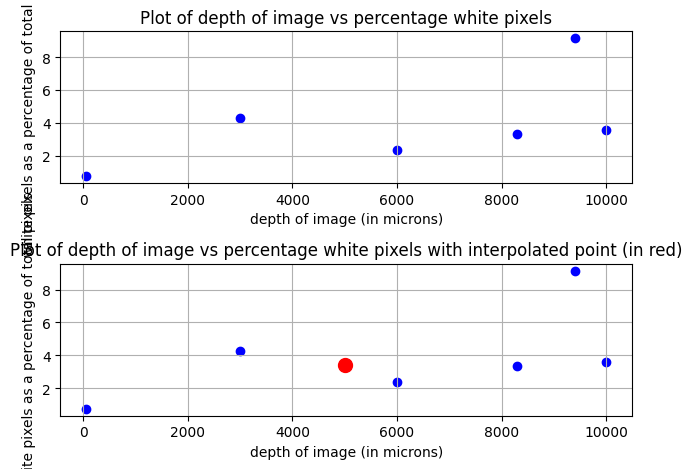

In [ ]:
# Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth1 = 5000

x = depths
y = white_percents

# You can also use 'quadratic', 'cubic', etc.
i = interp1d(x, y, kind='quadratic')
interpolate_point = i(interpolate_depth)
print(colored(
    f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue')
axs[1].set_title(
    'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point')


# Adjust layout to prevent overlap
plt.tight_layout(pad=3.0)
plt.show()


## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

- include: Mouse model is a good analysis but NOT a great one

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*

